In [51]:
from notebook_setup import setup
from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from kaysons_visual_config import * # Kayson's file. 

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome, plot_connectome_blockwise, compare_orderings

env = setup()

import numpy as np
from scipy.spatial.distance import squareform
from scipy.optimize import minimize
import networkx as nx
from netgraph import Graph
import matplotlib.pyplot as plt
from pypalettes import load_cmap

from pypalettes import load_cmap
cmap = load_cmap("Aurora")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from netgraph import Graph
from networkx.algorithms import community



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/scripts


In [52]:
subject_id = 206
experiment_name = "76_90000_samples_animal_206" 
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset") / experiment_name

data_dir = base_path / "generated_networks"
save_dir = base_path / "generated_networks_visualizations"
save_dir.mkdir(parents=True, exist_ok=True)

margin_x = 0.5
margin_y = 0.05
interesting_eta_and_gamma_combinations = [
    [-8+margin_x, 1-margin_y],  
    [3-margin_x, 1-margin_y], 
    [-0.8, 0.18],
    [3-margin_x, -0.1+margin_y], 
    [-8+margin_x, -0.1+margin_y],
    [-5, 0.5],

]

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'

# Store connectomes and parameters
connectomes = []
params = []

for parameter_combination in interesting_eta_and_gamma_combinations:
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
    
    connectomes.append(connectome)
    params.append((found_eta, found_gamma))
    
    parameter_combination.append(found_eta)
    parameter_combination.append(found_gamma)


Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta-7.484950065612793_gamma0.948494970798492_ruleMatchingIndex_id000.npy
Target (η, γ): (-7.5, 0.95)
Found  (η, γ): (-7.485, 0.948)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta2.484949827194214_gamma0.948494970798492_ruleMatchingIndex_id000.npy
Target (η, γ): (2.5, 0.95)
Found  (η, γ): (2.485, 0.948)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta-0.789297699928284_gamma0.179598659276962_ruleMatchingIndex_id000.npy
Target (η, γ): (-0.8, 0.18)
Found  (η, γ): (-0.789, 0.180)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/o

In [53]:
distance_matrices = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50.npy")
d = distance_matrices[subject_id]  

# Normalize distance matrix
d = (d - np.min(d)) / (np.max(d) - np.min(d))

# ============ Force-directed layout with distance weights ============

print("Creating distance-weighted graph for layout...")

# Create a complete weighted graph where edge weights represent desired distances
n_nodes = len(d)
G_distance = nx.Graph()
G_distance.add_nodes_from(range(n_nodes))
print(G_distance)
# Add edges with weights inversely proportional to distances
# (shorter distance = stronger attraction = higher weight)
epsilon = 1e-10
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        # Convert distance to weight: closer nodes should attract more
        # Using inverse distance as weight
        weight = 1.0 / (d[i, j] + epsilon)
        G_distance.add_edge(i, j, weight=weight)

# # Use spring layout with distance-derived weights
# print("Computing force-directed layout (this may take a moment)...")
# node_layout = nx.kamada_kawai_layout(  # spring_layout(
#     G, # onnectome,  # Use the actual connectome for layout
#     dist = G_distance, 
#     # weight='weight',  # Use the distance-based weights
#     # iterations=1,   # Increase for better convergence
#     # k=None,           # Optimal distance between nodes (auto-calculated)
#     # seed=42           # For reproducibility
# )

# # visualize node layout 
# for idx, (x, y) in enumerate(node_layout.values()):
#     plt.scatter(x, y)

Creating distance-weighted graph for layout...
Graph with 100 nodes and 0 edges


In [54]:
node_layout = nx.kamada_kawai_layout(  # spring_layout(
    G_distance, # onnectome,  # Use the actual connectome for layout
    # dist = G_distance, 
    # weight='weight',  # Use the distance-based weights
    # iterations=1,   # Increase for better convergence
    # k=None,           # Optimal distance between nodes (auto-calculated)
    # seed=42           # For reproducibility
)


# GOOD STUFF

In [55]:
import numpy as np

# Load distance matrix
subject_id = 206
distance_matrices = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50.npy")
d = distance_matrices[subject_id]  

# Normalize distance matrix
d = (d - np.min(d)) / (np.max(d) - np.min(d))

# ============================================
# Create distance-weighted graph for layout
# ============================================
print("Creating distance-weighted graph for layout...")

n_nodes = len(d)
G_distance = nx.Graph()
G_distance.add_nodes_from(range(n_nodes))

# Add edges with weights inversely proportional to distances
epsilon = 1e-10
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        # Convert distance to weight: closer nodes should attract more
        weight = 1.0 / (d[i, j] + epsilon)
        G_distance.add_edge(i, j, weight=weight)

# Compute layout based on distance matrix
print("Computing force-directed layout based on distance matrix...")
node_layout = nx.kamada_kawai_layout(G_distance)
print("Layout computed successfully!")

# Convert to numpy arrays for compatibility
for node in node_layout:
    node_layout[node] = np.array(node_layout[node])

# ============================================
# Create CONNECTOME graphs (for edges only)
# ============================================
connectome_graphs = []
for conn in connectomes:
    G_conn = nx.from_numpy_array(conn)
    connectome_graphs.append(G_conn)


Creating distance-weighted graph for layout...
Computing force-directed layout based on distance matrix...
Layout computed successfully!


In [56]:
for conn in connectomes: 
    print((d*conn).sum())

463.9547588966691
538.7825840593301
400.31687161237517
610.3186396804708
425.21469237698307
332.9356923978148


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len(np.unique(cis[:, i])))) for i in range(m))
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len(np.unique(cis[:, i])))) for i in range(m))
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len

  Found 4 communities
  Community sizes: [np.int64(26), np.int64(33), np.int64(18), np.int64(23)]


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len(np.unique(cis[:, i])))) for i in range(m))
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len(np.unique(cis[:, i])))) for i in range(m))
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len

  Found 47 communities
  Community sizes: [np.int64(1), np.int64(28), np.int64(1), np.int64(2), np.int64(6), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(5), np.int64(5), np.int64(2), np.int64(1), np.int64(4), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(3), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len(np.unique(cis[:, i])))) for i in range(m))
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len(np.unique(cis[:, i])))) for i in range(m))
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/bct/utils/miscellaneous_utilities.py:72: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  r = np.sum((np.max(len

...

D:
  Within left hemisphere:  mean=0.0704, std=0.2558
  Within right hemisphere: mean=0.0680, std=0.2517
  Between hemispheres:     mean=0.1288, std=0.3350
  Ratio (between/within):  1.8613

Creating visualization for D...
E:
  Within left hemisphere:  mean=0.1032, std=0.3042
  Within right hemisphere: mean=0.1152, std=0.3193
  Between hemispheres:     mean=0.0888, std=0.2845
  Ratio (between/within):  0.8132

Creating visualization for E...


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs

F:
  Within left hemisphere:  mean=0.1232, std=0.3287
  Within right hemisphere: mean=0.1272, std=0.3332
  Between hemispheres:     mean=0.0728, std=0.2598
  Ratio (between/within):  0.5815

Creating visualization for F...


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/miniconda3/envs


Visualization complete! Saved as '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks_visualizations/connectomes_visualization_distance_layout_connectome_edges_light_colors_no_separation_ratio.pdf'


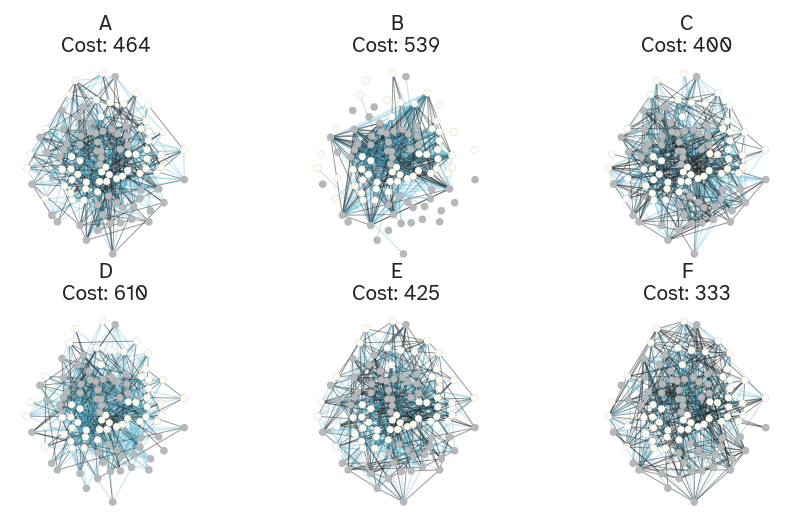

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks_visualizations/connectomes_visualization_distance_layout_connectome_edges_light_colors_no_separation_ratio.pdf


In [57]:

# ============================================
# Extract communities and create node colors
# ============================================
from netneurotools.modularity import consensus_modularity as netneurotools_modularity 

communities_arr = [] 
node_colors_arr = []
node_communities_arr = []

# Load colormap
# cmap = load_cmap("Antique")

for conn in connectomes:   
    communities, _, _ = netneurotools_modularity(conn)
    communities_arr.append(communities)
    
    # Create node_to_community dictionary
    node_to_community = {node_id: int(community_id) for node_id, community_id in enumerate(communities)}
    
    # Get number of unique communities and their sizes
    unique_communities = np.unique(communities)
    num_communities = len(unique_communities)
    partition_sizes = [np.sum(communities == comm) for comm in unique_communities]
    
    print(f"  Found {num_communities} communities")
    print(f"  Community sizes: {partition_sizes}")
    
    # Create color mapping
    # node_color = {node_id: "black" # cmap((community_id - 1) / max(num_communities - 1, 1)) 
    #               for node_id, community_id in node_to_community.items()}
    
    # node_colors_arr.append(node_color)
    # node_communities_arr.append(node_to_community)

# Define colors for the two groups of nodes
color_first_50 = "#FFFCF2" # default_colors["warms"]["YELLOW"]  # Left hemisphere
color_last_50 = "#b8b8b8" # default_colors["greens"]["LUXUARY_GREEN"]  # Right hemisphere

# Get the number of nodes from your graph G
num_nodes = len(G.nodes()) if hasattr(G, 'nodes') else 100

# Create node color dictionary
node_color_dict = {}
for i in range(num_nodes):
    if i < 50:
        node_color_dict[i] = color_first_50
    else:
        node_color_dict[i] = color_last_50

# Create an array of color dicts for each subplot
node_colors_arr = [node_color_dict.copy() for _ in range(len(labels))]

# Convert distance matrix to edge_length dictionary (for layout only)
edge_length = {}
for source, target in G.edges():
    edge_length[(source, target)] = d[source, target]/10


# ============================================
# Create edge properties for EACH connectome
# ============================================
labels = ['A', 'B', 'C', 'D', 'E', 'F']
edge_color_dicts = []
edge_width_dicts = []
edge_alpha_dicts = []

# Define colors for different connection types
within_color = "#232324" # HALF BLACK within hemisphere
between_hemispheres_color ="#3FA5C4" # '#591154' # #9B59B6'  # PURPLER for cross-hemisphere connections

# First, collect all strengths to find min and max for normalization
all_strengths = []
for conn in connectomes:
    for i in range(len(conn)):
        for j in range(i+1, len(conn)):
            if conn[i, j] > 0:  # Only non-zero connections
                all_strengths.append(conn[i, j])
                
min_strength = float(np.min(all_strengths))
max_strength = float(np.max(all_strengths))
print(min_strength, max_strength)

print(f"Strength range: {min_strength:.4f} to {max_strength:.4f}")

for conn_idx, (conn, G_conn) in enumerate(zip(connectomes, connectome_graphs)):
    edge_color_dict = {}
    edge_width_dict = {}
    edge_alpha_dict = {}
    
    # Get all edges that exist in THIS connectome's graph
    for source, target in G_conn.edges():
        # Get connection strength from THIS connectome
        # strength = float(conn[source, target])
        
        # # Normalize strength to [0, 1] range
        # normalized_strength = (strength - min_strength) / (max_strength - min_strength + 1e-10)
        
        # # Map normalized strength to alpha range [0.2, 0.8]
        # alpha_val = 0.4 + (normalized_strength * 0.6)  # Maps [0,1] to [0.4, 1.0]

        # # Map normalized strength to width range (adjust multipliers as needed)
        # width_val = float(1 + (normalized_strength * 6))  # Maps [0,1] to [1.0, 7.0]

        # Classify the edge
        factor = 0.5
        if (source < 50 and target < 50) or (source >= 50 and target >= 50):
            # Within hemisphere
            edge_color_dict[(source, target)] = within_color
            edge_width_dict[(source, target)] = 2.0 * factor
            edge_alpha_dict[(source, target)] = 1.0 * factor
        else:
            # Between hemispheres - emphasize these
            edge_color_dict[(source, target)] = between_hemispheres_color
            edge_width_dict[(source, target)] = 3.0 * factor
            edge_alpha_dict[(source, target)] = 0.5 * factor
    
    edge_color_dicts.append(edge_color_dict)
    edge_width_dicts.append(edge_width_dict)
    edge_alpha_dicts.append(edge_alpha_dict)

# ============================================
# Optional: Arrange nodes to separate hemispheres
# ============================================
node_positions_separated = {}
separation = 0  # Adjust this value to increase/decrease separation

for i in range(n_nodes):
    x, y = node_layout[i]
    if i < 50:
        # Shift left hemisphere nodes to the left
        node_positions_separated[i] = np.array([x - separation, y])
    else:
        # Shift right hemisphere nodes to the right
        node_positions_separated[i] = np.array([x + separation, y])


# ============================================
# Create visualizations
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(viz.cm_to_inch((18, 10))), dpi=150)
axes = axes.flatten()

g_arr = []

# Process each connectome
for idx, (conn, label) in enumerate(zip(connectomes, labels)):
    
    # Calculate statistics
    within_left = conn[:50, :50]
    within_right = conn[50:, 50:]
    between = np.concatenate([conn[:50, 50:].flatten(), conn[50:, :50].flatten()])
    
    print(f"{label}:")
    print(f"  Within left hemisphere:  mean={within_left.mean():.4f}, std={within_left.std():.4f}")
    print(f"  Within right hemisphere: mean={within_right.mean():.4f}, std={within_right.std():.4f}")
    print(f"  Between hemispheres:     mean={between.mean():.4f}, std={between.std():.4f}")
    print(f"  Ratio (between/within):  {between.mean() / ((within_left.mean() + within_right.mean())/2):.4f}")



    print(f"\nCreating visualization for {label}...")
    plt.sca(axes[idx])
    

    # Use the CONNECTOME-SPECIFIC graph but SHARED distance-based layout
    g = Graph(connectome_graphs[idx],  # Each connectome has its own edges
              node_color=node_colors_arr[idx],
              node_size=4,
              node_edge_width=0.1,
              edge_alpha=edge_alpha_dicts[idx],  # Different for each connectome, scaled [0.2, 0.8]
              edge_color=edge_color_dicts[idx],  # Different for each connectome
              edge_width=edge_width_dicts[idx],  # Different for each connectome, correlated with alpha
              node_layout=node_positions_separated,  # SAME layout for all (from distance matrix)
              edge_layout='straight', # bundled',
              edge_layout_kwargs=dict(k=2000),
              ax=axes[idx], 
              scale=(12.0, 10.0)
    )
    
    # axes[idx].set_title(f'{label}\nRatio (between/within): {between.mean() / ((within_left.mean() + within_right.mean())/2):.4f}')
    axes[idx].set_title(f'{label}\nCost: {(d*conn).sum():.0f}')
    g_arr.append(g)
    
save_file_path = save_dir / 'connectomes_visualization_distance_layout_connectome_edges_light_colors_no_separation_ratio.pdf'
plt.savefig(save_file_path, dpi=150, bbox_inches='tight')
print(f"\nVisualization complete! Saved as '{save_file_path}'")
plt.show()
print(save_file_path)